# NBP Method 2 vs Method 3 Comparison

This notebook compares two candidate calculations for `nbp` using ACCESS-MOPPy test data:

- **Method 2** (tile-sum formula; no extra tile fraction on 907-909):
  $$\text{nbp}_{m2} = \frac{\text{fld\_s03i262} - \text{fld\_s03i293} + \left(\sum_{tiles}(\text{fld\_s03i907} + \text{fld\_s03i908} + \text{fld\_s03i909}) \times \text{fld\_s03i395} \times -3.1688087814029657\times10^{-11}\right)}{\text{fld\_s03i395}}$$

- **Method 3 (raw tracer form)**:
  $$\text{nbp}_{m3,raw} = \text{fld\_s03i100} \times \frac{12}{44.01}$$

- **Method 3 (aligned diagnostic form)**:
  $$\text{nbp}_{m3,aligned} = -\frac{\text{fld\_s03i100} \times 12/44.01}{\text{fld\_s03i395}}$$

In [9]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [10]:
# Configuration
DATA_ROOT_ENV_VAR = 'ACCESS_MOPPY_DATA_ROOT'
MONTHLY_FILE_GLOB = 'output*/atmosphere/netCDF/*_mon.nc'

MAX_FILES = int(os.getenv('ACCESS_MOPPY_NBP_COMPARE_MAX_FILES', '2'))
TIME_STEPS = int(os.getenv('ACCESS_MOPPY_NBP_COMPARE_TIME_STEPS', '3'))
ABS_TOL = float(os.getenv('ACCESS_MOPPY_NBP_COMPARE_ATOL', '1e-6'))

WOOD_RESP_SCALE = -3.1688087814029657e-11
CO2_TO_C_SCALE = 12.0 / 44.01

REQUIRED_VARS = [
    'fld_s03i100',
    'fld_s03i262',
    'fld_s03i293',
    'fld_s03i317',
    'fld_s03i395',
    'fld_s03i907',
    'fld_s03i908',
    'fld_s03i909',
]

In [11]:
data_root_value = os.getenv(DATA_ROOT_ENV_VAR)
if not data_root_value:
    raise RuntimeError(f'{DATA_ROOT_ENV_VAR} is not set')

data_root = Path(data_root_value)
if not data_root.exists():
    raise FileNotFoundError(f'Data root does not exist: {data_root}')

files = sorted(data_root.glob(MONTHLY_FILE_GLOB))[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No files found with pattern: {MONTHLY_FILE_GLOB}')

print(f'Data root: {data_root}')
print(f'Using {len(files)} files (MAX_FILES={MAX_FILES}):')
for f in files:
    print(' -', f)
print(f'Limiting to first {TIME_STEPS} timesteps')

Data root: /home/romain/PROJECTS/CMIP7_Test_data/esm-historical
Using 2 files (MAX_FILES=2):
 - /home/romain/PROJECTS/CMIP7_Test_data/esm-historical/output101/atmosphere/netCDF/aiihca.pa-195101_mon.nc
 - /home/romain/PROJECTS/CMIP7_Test_data/esm-historical/output101/atmosphere/netCDF/aiihca.pa-195102_mon.nc
Limiting to first 3 timesteps


In [12]:
ds = xr.open_mfdataset(
    [str(p) for p in files],
    combine='by_coords',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    join='outer',
)

missing_vars = [v for v in REQUIRED_VARS if v not in ds.variables]
if missing_vars:
    raise KeyError(f'Missing required variables: {missing_vars}')

ds = ds[REQUIRED_VARS].isel(time=slice(0, TIME_STEPS)).load()
ds

<xarray.Dataset> Size: 16MB
Dimensions:           (time: 2, lat: 145, lon: 192, pseudo_level_0: 17)
Coordinates:
  * time              (time) datetime64[ns] 16B 1951-01-16T12:00:00 1951-02-15
  * lat               (lat) float64 1kB -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * lon               (lon) float64 2kB 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * pseudo_level_0    (pseudo_level_0) int32 68B 1 2 3 4 5 6 ... 13 14 15 16 17
    surface_altitude  (lat, lon) float64 223kB 2.802e+03 2.802e+03 ... 0.0 0.0
    height            float64 8B 10.0
    height_0          float64 8B 1.5
    pseudo_level_1    int32 4B 1
Data variables:
    fld_s03i100       (time, lat, lon) float32 223kB 0.0 0.0 0.0 ... nan nan nan
    fld_s03i262       (time, lat, lon) float32 223kB 0.0 0.0 0.0 ... nan nan nan
    fld_s03i293       (time, lat, lon) float32 223kB 0.0 0.0 0.0 ... nan nan nan
    fld_s03i317       (time, pseudo_level_0, lat, lon) float32 4MB 0.0 ... nan
    fld_s03i395       (time, lat, lon) float32 223kB 1.0 1.0 1.0 ... nan nan nan
    fld_s03i907       (time, pseudo_level_0, lat, lon) float32 4MB 0.0 ... nan
    fld_s03i908       (time, pseudo_level_0, lat, lon) float32 4MB 0.0 ... nan
    fld_s03i909       (time, pseudo_level_0, lat, lon) float32 4MB 0.0 ... nan
Attributes:
    history:      File /scratch/p66/rml599/access-esm/archive/esm-historical-...
    Conventions:  CF-1.6
    source:       Data from Met Office Unified Model
    um_version:   7.3

In [13]:
# Method 2 (updated formula: wood respiration already tile-fractioned)
wood_resp_sum = ds['fld_s03i907'] + ds['fld_s03i908'] + ds['fld_s03i909']
summed_tile_wood_resp = wood_resp_sum.sum(dim='pseudo_level_0') * ds['fld_s03i395']
method2 = (ds['fld_s03i262'] - ds['fld_s03i293'] + summed_tile_wood_resp * WOOD_RESP_SCALE) / ds['fld_s03i395']

# Method 3 variants
method3_raw = ds['fld_s03i100'] * CO2_TO_C_SCALE
method3_aligned = -method3_raw / ds['fld_s03i395']

# Primary comparison in this notebook uses the aligned tracer variant.
method3 = method3_aligned

valid = (ds['fld_s03i395'] > 0) & np.isfinite(method2) & np.isfinite(method3_raw) & np.isfinite(method3_aligned)
diff_raw = (method2 - method3_raw).where(valid)
diff_aligned = (method2 - method3_aligned).where(valid)
diff = diff_aligned
abs_diff_raw = np.abs(diff_raw)
abs_diff_aligned = np.abs(diff_aligned)
abs_diff = abs_diff_aligned

valid_count = int(valid.sum().item())
print('Valid points:', valid_count)
if valid_count == 0:
    raise RuntimeError('No valid points for comparison')

Valid points: 10865


In [14]:
# Compact dataframe for plotting
df = xr.Dataset(
    {
        'method2': method2,
        'method3_raw': method3_raw,
        'method3_aligned': method3_aligned,
        'abs_diff_raw': abs_diff_raw,
        'abs_diff_aligned': abs_diff_aligned,
    }
).to_dataframe().reset_index()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['method2', 'method3_raw', 'method3_aligned'])

# Keep a representative sample for scatter clarity
sample_n = min(20000, len(df))
if len(df) > sample_n:
    df_sample = df.sample(sample_n, random_state=42)
else:
    df_sample = df.copy()

print(f'Plotting {len(df_sample)} sampled points out of {len(df)} total valid points')

Plotting 10865 sampled points out of 10865 total valid points


/tmp/ipykernel_256277/1743063807.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


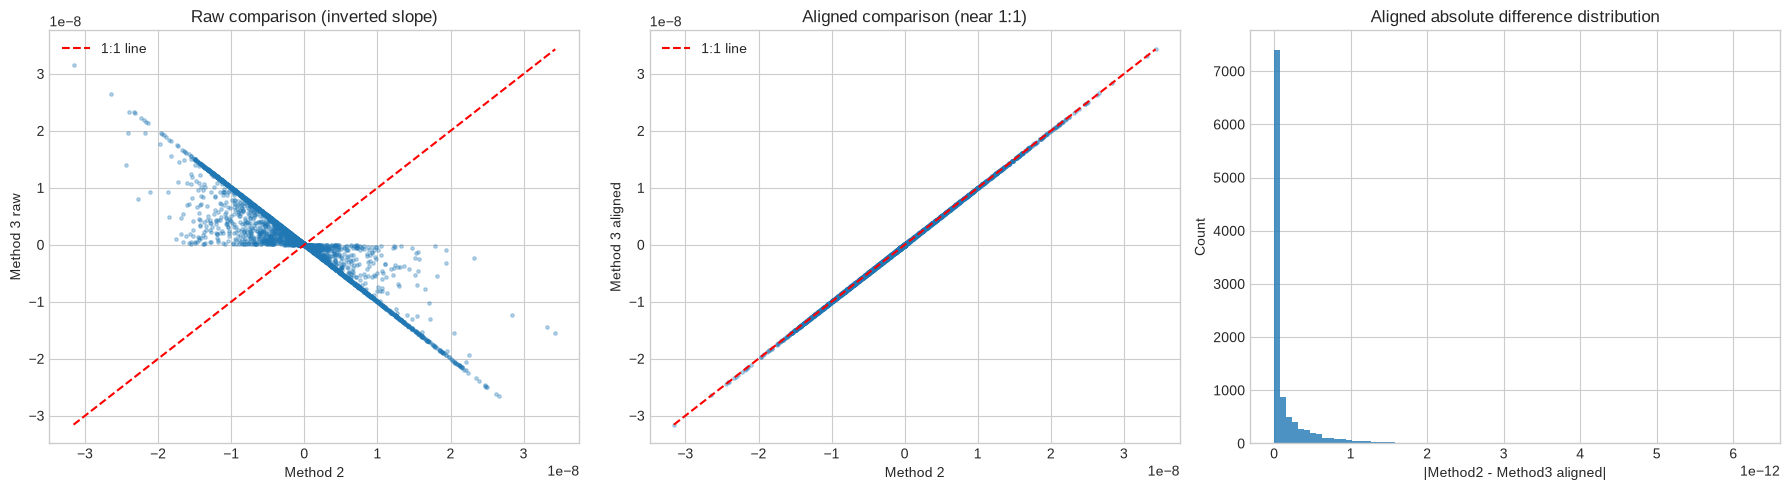

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter 1: method 2 vs raw method 3
axes[0].scatter(df_sample['method2'], df_sample['method3_raw'], s=6, alpha=0.3)
xy_min = min(df_sample['method2'].min(), df_sample['method3_raw'].min())
xy_max = max(df_sample['method2'].max(), df_sample['method3_raw'].max())
axes[0].plot([xy_min, xy_max], [xy_min, xy_max], 'r--', lw=1.5, label='1:1 line')
axes[0].set_xlabel('Method 2')
axes[0].set_ylabel('Method 3 raw')
axes[0].set_title('Raw comparison (inverted slope)')
axes[0].legend()

# Scatter 2: method 2 vs aligned method 3
axes[1].scatter(df_sample['method2'], df_sample['method3_aligned'], s=6, alpha=0.3)
xy_min2 = min(df_sample['method2'].min(), df_sample['method3_aligned'].min())
xy_max2 = max(df_sample['method2'].max(), df_sample['method3_aligned'].max())
axes[1].plot([xy_min2, xy_max2], [xy_min2, xy_max2], 'r--', lw=1.5, label='1:1 line')
axes[1].set_xlabel('Method 2')
axes[1].set_ylabel('Method 3 aligned')
axes[1].set_title('Aligned comparison (near 1:1)')
axes[1].legend()

# Histogram of aligned absolute differences
axes[2].hist(df_sample['abs_diff_aligned'], bins=80, color='tab:blue', alpha=0.8)
#axes[2].axvline(ABS_TOL, color='red', linestyle='--', linewidth=2, label=f'ABS_TOL={ABS_TOL:g}')
axes[2].set_xlabel('|Method2 - Method3 aligned|')
axes[2].set_ylabel('Count')
axes[2].set_title('Aligned absolute difference distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

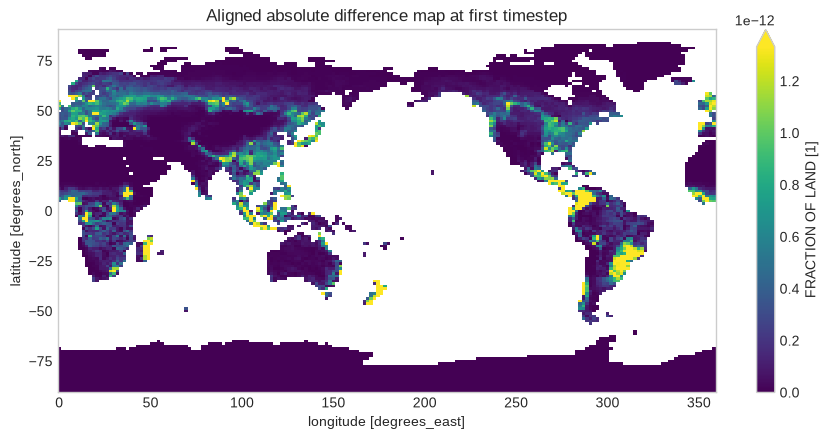

In [16]:
# Optional map: aligned absolute difference for the first timestep
t0 = abs_diff_aligned.isel(time=0)

plt.figure(figsize=(9, 4.5))
t0.plot(cmap='viridis', robust=True)
plt.title('Aligned absolute difference map at first timestep')
plt.tight_layout()
plt.show()